# Transferring to MSK-CHORD Patient Data

The purpose of this notebook is to transfer the cell line RSi model to patient data in the MSK-CHORD Database. This notebook can also serve as biomarker analysis.

In [1]:
import argparse
import os
import random
import shutil
import time
import warnings
from enum import Enum
import pandas as pd

import argparse
import torch
import torch.nn.parallel
import torch.distributed as dist
import torch.optim
import torch.multiprocessing as mp
import torch.utils.data
import torch.utils.data.distributed

from prettytable import PrettyTable

from src.model.compound import ECFPCompoundModel, ChemBERTaCompoundModel, DrugEmbeddingCompoundModel
from src.model.model.drug_response_model import DrugResponseModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline, RobertaModel, RobertaTokenizer

from src.utils.data import CompoundEncoder
from src.utils.tree import MutTreeParser
from src.utils.data.dataset import DrugResponseDataset, DrugResponseCollator, DrugResponseSampler, DrugBatchSampler, DrugDataset, CellLineBatchSampler
from src.utils.trainer import DrugResponseTrainer, DrugTrainer, DrugResponseFineTuner
import numpy as np
import torch.nn as nn
import pickle
import pubchempy as pcp
import statistics as s
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import math
from operator import itemgetter
from scipy.stats import ttest_ind

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import  StepLR
from torch.nn.utils import prune
from sklearn import metrics
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm
import numpy as np
import copy
from transformers import get_linear_schedule_with_warmup
from src.utils.trainer import CCCLoss
from src.utils.data import move_to
import copy
from torch.nn import functional as F
import pickle

ModuleNotFoundError: No module named 'torch'

## Load in results dictionary

In [3]:
with open("results_g2d.pkl", "rb") as handle:
    results = pickle.load(handle)

## Code to stratify results

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

plt.rcParams['svg.fonttype'] = 'none'


def load_drug_subset(survival_table, drug_name):
    df = pd.read_csv(survival_table, sep="\t")

    if "RSI_DRUG" not in df.columns:
        raise ValueError("Expected column 'RSI_DRUG' in survival table.")

    df = df[df["RSI_DRUG"] == drug_name].copy()
    if df.empty:
        raise ValueError(f"No rows found for drug: {drug_name}")

    dur = pd.to_numeric(df["PFS_MONTHS"]).to_numpy(dtype=float)

    if "EVENT" in df.columns:
        ev = pd.to_numeric(df["EVENT"]).astype(int).to_numpy()
    else:
        ev = df["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    time_cols = [c for c in df.columns if c.startswith("time_")]
    times = None
    surv = None
    if time_cols:
        times = np.array([float(c.replace("time_", "")) for c in time_cols])
        order = np.argsort(times)
        times = times[order]
        time_cols = [time_cols[i] for i in order]
        surv = df[time_cols].to_numpy(dtype=float)

    return df, surv, times, dur, ev, time_cols


def median_surv_time(curve, t_grid):
    below = np.where(curve <= 0.5)[0]
    return t_grid[below[0]] if below.size else t_grid[-1]


def _plot_km(dur, ev, sensitive_mask, resistant_mask, title, ylabel, output_svg):
    p_value = logrank_test(
        dur[resistant_mask], dur[sensitive_mask],
        event_observed_A=ev[resistant_mask],
        event_observed_B=ev[sensitive_mask]
    ).p_value

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(
        dur[sensitive_mask],
        ev[sensitive_mask],
        label=f"Pred. Sensitive ({sensitive_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False)

    kmf.fit(
        dur[resistant_mask],
        ev[resistant_mask],
        label=f"Pred. Resistant ({resistant_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False)

    plt.title(title)
    plt.xlabel("PFS Months")
    plt.ylabel(ylabel)
    plt.grid(False)
    plt.legend(title=f"P = {p_value:.3g}")
    plt.tight_layout()

    if output_svg is not None:
        plt.savefig(output_svg, format="svg", bbox_inches="tight")

    plt.show()
    return p_value


def stratify_by_predicted_median(survival_table, drug_name, output_svg=None):
    df, surv, times, dur, ev, time_cols = load_drug_subset(survival_table, drug_name)

    if surv is None or times is None:
        raise ValueError("No survival probability columns found (expected columns like time_0.0000).")

    med_surv = np.array([median_surv_time(surv[i], times) for i in range(surv.shape[0])])
    cut = np.median(med_surv)

    sensitive = med_surv >= cut
    resistant = ~sensitive

    _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} Kaplan-Meier Curves by Predicted Median Survival",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    df = df.copy()
    df["predicted_median_survival"] = med_surv
    df["median_threshold"] = cut
    df["predicted_group"] = np.where(sensitive, "sensitive", "resistant")
    return df


def stratify_by_predicted_auc(survival_table, drug_name, auc_threshold=None, output_svg=None):
    df, _, _, dur, ev, _ = load_drug_subset(survival_table, drug_name)

    if "predicted_auc" not in df.columns:
        raise ValueError("Expected column 'predicted_auc' in survival table.")

    auc = pd.to_numeric(df["predicted_auc"]).to_numpy(dtype=float)
    cut = float(np.median(auc)) if auc_threshold is None else float(auc_threshold)

    sensitive = auc <= cut
    resistant = ~sensitive

    _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} Kaplan-Meier Curves by Predicted AUC",
        ylabel="Survival Probability",
        output_svg=output_svg,
    )

    df = df.copy()
    df["auc_threshold"] = cut
    df["auc_group"] = np.where(sensitive, "sensitive", "resistant")
    return df


def stratify_by_risk_score(survival_table, drug_name, risk_threshold=None, output_svg=None):
    df, _, _, dur, ev, _ = load_drug_subset(survival_table, drug_name)

    if "risk_score" not in df.columns:
        raise ValueError("Expected column 'risk_score' in survival table.")

    risk = pd.to_numeric(df["risk_score"]).to_numpy(dtype=float)
    cut = float(np.median(risk)) if risk_threshold is None else float(risk_threshold)

    sensitive = risk <= cut
    resistant = ~sensitive

    _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} Kaplan-Meier Curves by Risk Score",
        ylabel="Survival Probability",
        output_svg=output_svg,
    )

    df = df.copy()
    df["risk_threshold"] = cut
    df["risk_group"] = np.where(sensitive, "sensitive", "resistant")
    return df


def stratify_by_risk_score_threshold(survival_table, drug_name, output_svg=None):
    df, _, _, dur, ev, _ = load_drug_subset(survival_table, drug_name)

    required_cols = {"risk_score", "risk_cutoff", "predicted_group"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(
            f"Expected thresholded risk-score columns in survival table, missing: {missing}"
        )

    risk = pd.to_numeric(df["risk_score"]).to_numpy(dtype=float)
    cut = pd.to_numeric(df["risk_cutoff"]).to_numpy(dtype=float)

    if np.isnan(cut).any():
        raise ValueError("Found missing values in 'risk_cutoff'.")

    sensitive = (df["predicted_group"].astype(str) == "sensitive").to_numpy()
    resistant = (df["predicted_group"].astype(str) == "resistant").to_numpy()

    if not np.all((risk <= cut) == sensitive):
        print("Warning: predicted_group is not perfectly consistent with risk_score <= risk_cutoff for all rows.")

    _plot_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} Kaplan-Meier Curves by Validation-Derived Risk Threshold",
        ylabel="Survival Probability",
        output_svg=output_svg,
    )

    df = df.copy()
    return df


## Change Survival Table Accordingly

In [68]:
# Surival probabilities/curves
survival_table1 = "msk_embedding_transfer_cox_ph_1_survival_probabilities.tsv"
survival_table2 = "msk_embedding_transfer_mlp_cox_ph_1_survival_probabilities.tsv"

# Survival risk scores
survival_table3 = "msk_embedding_transfer_cox_ph_risk_1_risk_scores.tsv"
survival_table4= "msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv"

In [80]:
survival_table5 = "msk_embedding_transfer_mlp_cox_ph_risk_0505_risk_scores.tsv"
survival_table6 = "msk_embedding_transfer_mlp_cox_ph_risk_0506_risk_scores.tsv"

### Stratify by risk score

#### 5-FU

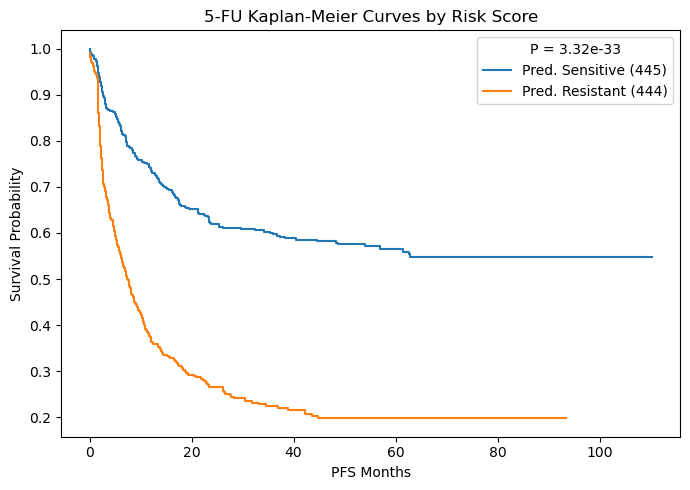

In [8]:
df3 = stratify_by_risk_score(
    survival_table=survival_table5,
    drug_name="5-FU",
    #output_svg="5-fu_risk_km.svg",
)

#### Gemcitabine

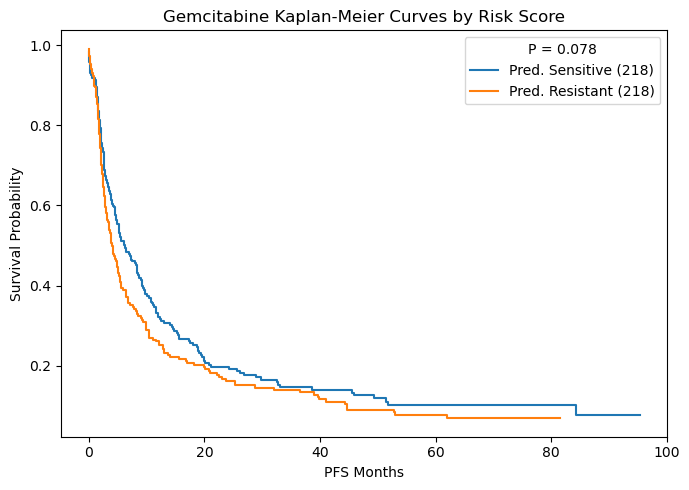

In [13]:
df3 = stratify_by_risk_score(
    survival_table=survival_table5,
    drug_name="Gemcitabine",
    #output_svg="gemcitabine_risk_km.svg",
)

#### Camptothecin 

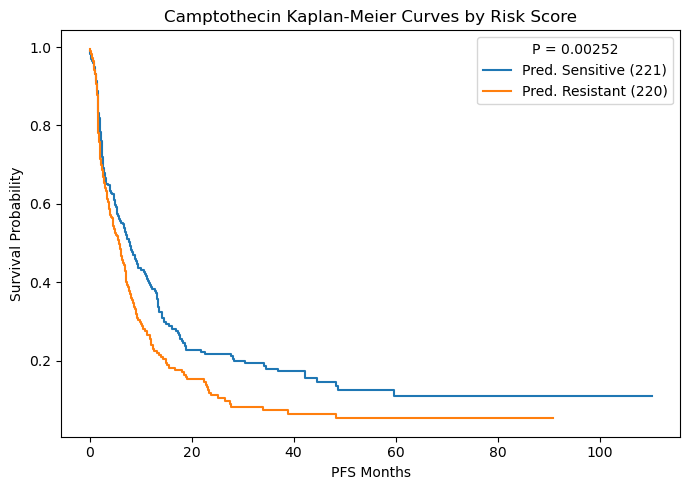

In [14]:
df3 = stratify_by_risk_score(
    survival_table=survival_table5,
    drug_name="Camptothecin",
    #output_svg="camptothecin_risk_km.svg",
)

### Stratify simply by AUC

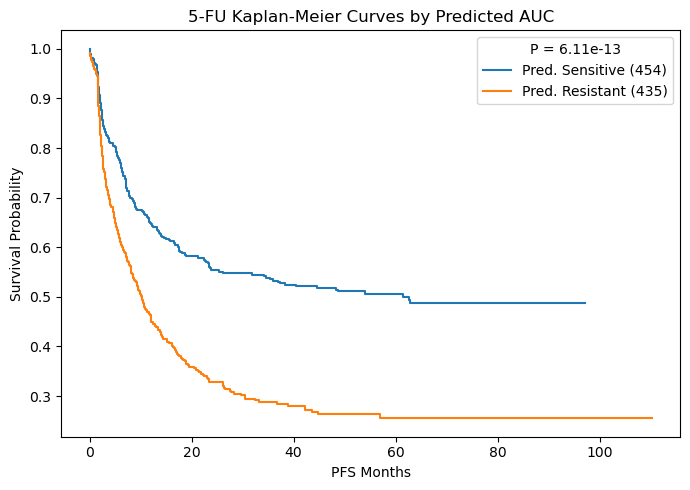

In [16]:
df2 = stratify_by_predicted_auc(
    survival_table=survival_table5,
    drug_name="5-FU",
    #output_svg="Camptothecin_auc_km.svg",
)

### Stratify by optimized risk score

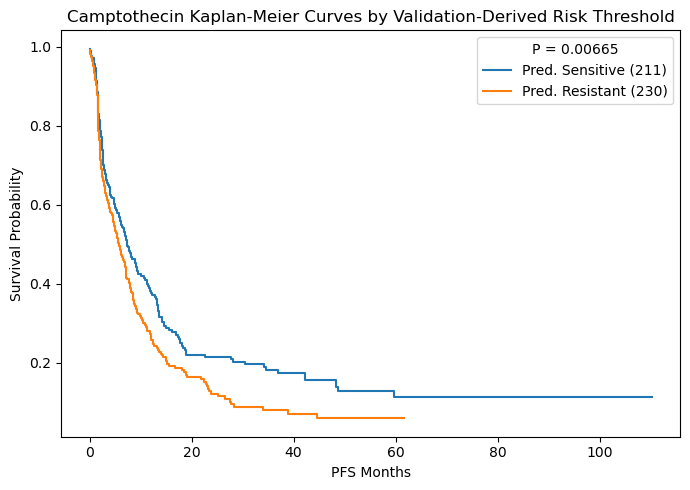

In [25]:
df2 = stratify_by_risk_score_threshold(
    survival_table="msk_embedding_transfer_mlp_cox_ph_risk_optimized_1_test_risk_assignments.tsv",
    drug_name="Camptothecin",
    #output_svg="cisplatin_validation_threshold_km.svg",
)

## Stratify by drug and cancer type

### Stratify by Risk Score

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

plt.rcParams['svg.fonttype'] = 'none'


def median_surv_time(curve, t_grid):
    below = np.where(curve <= 0.5)[0]
    return t_grid[below[0]] if below.size else t_grid[-1]


def _prepare_drug_cancer_subset(survival_table, patient_table, drug_name, cancer_type):
    surv_df = pd.read_csv(survival_table, sep="\t")
    patient_df = pd.read_csv(patient_table, sep="\t")

    required_surv_cols = {"SAMPLE_ID", "RSI_DRUG", "PFS_MONTHS"}
    missing_surv = required_surv_cols - set(surv_df.columns)
    if missing_surv:
        raise ValueError(f"Missing columns in survival table: {missing_surv}")

    required_patient_cols = {"SAMPLE_ID", "CANCER_TYPE"}
    missing_patient = required_patient_cols - set(patient_df.columns)
    if missing_patient:
        raise ValueError(f"Missing columns in patient table: {missing_patient}")

    merged = surv_df.merge(
        patient_df[["SAMPLE_ID", "CANCER_TYPE"]].drop_duplicates(),
        on="SAMPLE_ID",
        how="left"
    )

    drug_df = merged[merged["RSI_DRUG"] == drug_name].copy()
    if drug_df.empty:
        raise ValueError(f"No rows found for drug: {drug_name}")

    cancer_df = drug_df[drug_df["CANCER_TYPE"] == cancer_type].copy()
    if cancer_df.empty:
        raise ValueError(f"No rows found for drug={drug_name} and cancer_type={cancer_type}")

    dur = pd.to_numeric(cancer_df["PFS_MONTHS"]).to_numpy(dtype=float)
    if "EVENT" in cancer_df.columns:
        ev = pd.to_numeric(cancer_df["EVENT"]).astype(int).to_numpy()
    else:
        ev = cancer_df["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    return merged, drug_df, cancer_df, dur, ev


def _compute_hazard_ratio(dur, ev, sensitive_mask, resistant_mask):
    group = np.full(len(dur), np.nan)
    group[sensitive_mask] = 0
    group[resistant_mask] = 1

    cox_df = pd.DataFrame({
        "PFS_MONTHS": pd.to_numeric(dur, errors="coerce"),
        "EVENT": pd.to_numeric(ev, errors="coerce"),
        "predicted_resistant": group,
    }).dropna()

    if cox_df["predicted_resistant"].nunique() < 2:
        return np.nan, np.nan, np.nan

    try:
        cph = CoxPHFitter()
        cph.fit(cox_df, duration_col="PFS_MONTHS", event_col="EVENT")
        hr = float(np.exp(cph.params_["predicted_resistant"]))
        hr_lower = float(np.exp(cph.confidence_intervals_.loc["predicted_resistant"].iloc[0]))
        hr_upper = float(np.exp(cph.confidence_intervals_.loc["predicted_resistant"].iloc[1]))
        return hr, hr_lower, hr_upper
    except Exception:
        return np.nan, np.nan, np.nan


def _plot_drug_cancer_km(dur, ev, sensitive_mask, resistant_mask, title, ylabel, output_svg=None):
    p_value = logrank_test(
        dur[resistant_mask], dur[sensitive_mask],
        event_observed_A=ev[resistant_mask],
        event_observed_B=ev[sensitive_mask]
    ).p_value

    hr, hr_lower, hr_upper = _compute_hazard_ratio(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive_mask,
        resistant_mask=resistant_mask,
    )

    sensitive_color = "#1f77b4"
    resistant_color = "#e4572e"

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(
        dur[sensitive_mask],
        ev[sensitive_mask],
        label=f"Pred. Sensitive ({sensitive_mask.sum()})"
    )
    ax = kmf.plot_survival_function(ci_show=False, color=sensitive_color, linewidth=2.0)

    kmf.fit(
        dur[resistant_mask],
        ev[resistant_mask],
        label=f"Pred. Resistant ({resistant_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False, color=resistant_color, linewidth=2.0, ax=ax)

    plt.title(title)
    plt.xlabel("PFS Months")
    plt.ylabel(ylabel)
    plt.grid(False)

    plt.xlim(0, 104)
    plt.xticks(np.arange(0, 101, 20))
    plt.ylim(0.0, 1.0)
    plt.yticks(np.arange(0.0, 1.01, 0.2))

    if np.isfinite(hr):
        legend_title = f"P = {p_value:.3g}\nHR = {hr:.2f} ({hr_lower:.2f}-{hr_upper:.2f})"
    else:
        legend_title = f"P = {p_value:.3g}\nHR = nan"

    plt.legend(title=legend_title)
    plt.tight_layout()

    if output_svg is not None:
        plt.savefig(output_svg, format="svg", bbox_inches="tight")

    plt.show()
    return p_value, hr, hr_lower, hr_upper


def stratify_drug_cancer_by_predicted_median(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    threshold_scope="drug_only",
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    time_cols = [c for c in merged.columns if c.startswith("time_")]
    if not time_cols:
        raise ValueError("No survival probability columns found.")

    times = np.array([float(c.replace("time_", "")) for c in time_cols])
    order = np.argsort(times)
    times = times[order]
    time_cols = [time_cols[i] for i in order]

    if threshold_scope == "drug_only":
        threshold_df = drug_df
    elif threshold_scope == "drug_and_cancer":
        threshold_df = cancer_df
    else:
        raise ValueError("threshold_scope must be 'drug_only' or 'drug_and_cancer'")

    S_threshold = threshold_df[time_cols].to_numpy(dtype=float)
    med_surv_threshold = np.array([
        median_surv_time(S_threshold[i], times) for i in range(S_threshold.shape[0])
    ])
    cut = np.median(med_surv_threshold)

    S_eval = cancer_df[time_cols].to_numpy(dtype=float)
    med_surv_eval = np.array([
        median_surv_time(S_eval[i], times) for i in range(S_eval.shape[0])
    ])

    sensitive = med_surv_eval >= cut
    resistant = ~sensitive

    scope_label = "all drug-treated patients" if threshold_scope == "drug_only" else "drug + cancer subset"
    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nThreshold from {scope_label}",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["predicted_median_survival"] = med_surv_eval
    out_df["median_cutoff_used"] = cut
    out_df["predicted_group"] = np.where(sensitive, "sensitive", "resistant")
    out_df["threshold_scope"] = threshold_scope
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


def stratify_drug_cancer_by_risk_score(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    threshold_scope="drug_only",
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    if "risk_score" not in merged.columns:
        raise ValueError("Missing column 'risk_score' in survival table.")

    if threshold_scope == "drug_only":
        threshold_df = drug_df
    elif threshold_scope == "drug_and_cancer":
        threshold_df = cancer_df
    else:
        raise ValueError("threshold_scope must be 'drug_only' or 'drug_and_cancer'")

    risk_threshold = pd.to_numeric(threshold_df["risk_score"]).to_numpy(dtype=float)
    cut = np.median(risk_threshold)

    risk_eval = pd.to_numeric(cancer_df["risk_score"]).to_numpy(dtype=float)

    sensitive = risk_eval <= cut
    resistant = ~sensitive

    scope_label = "all drug-treated patients" if threshold_scope == "drug_only" else "drug + cancer subset"
    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nRisk threshold from {scope_label}",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["risk_cutoff_used"] = cut
    out_df["risk_group"] = np.where(sensitive, "sensitive", "resistant")
    out_df["threshold_scope"] = threshold_scope
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


def stratify_drug_cancer_by_predicted_auc(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    threshold_scope="drug_only",
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    if "predicted_auc" not in merged.columns:
        raise ValueError("Missing column 'predicted_auc' in survival table.")

    if threshold_scope == "drug_only":
        threshold_df = drug_df
    elif threshold_scope == "drug_and_cancer":
        threshold_df = cancer_df
    else:
        raise ValueError("threshold_scope must be 'drug_only' or 'drug_and_cancer'")

    auc_threshold = pd.to_numeric(threshold_df["predicted_auc"]).to_numpy(dtype=float)
    cut = np.median(auc_threshold)

    auc_eval = pd.to_numeric(cancer_df["predicted_auc"]).to_numpy(dtype=float)

    sensitive = auc_eval <= cut
    resistant = ~sensitive

    scope_label = "all drug-treated patients" if threshold_scope == "drug_only" else "drug + cancer subset"
    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nAUC threshold from {scope_label}",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["auc_cutoff_used"] = cut
    out_df["auc_group"] = np.where(sensitive, "sensitive", "resistant")
    out_df["threshold_scope"] = threshold_scope
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


def stratify_drug_cancer_by_risk_score_threshold(
    survival_table,
    patient_table,
    drug_name,
    cancer_type,
    output_svg=None,
):
    merged, drug_df, cancer_df, dur, ev = _prepare_drug_cancer_subset(
        survival_table, patient_table, drug_name, cancer_type
    )

    required_cols = {"risk_score", "risk_cutoff", "predicted_group"}
    missing = required_cols - set(merged.columns)
    if missing:
        raise ValueError(
            f"Missing thresholded risk-score columns in survival table: {missing}"
        )

    risk = pd.to_numeric(cancer_df["risk_score"]).to_numpy(dtype=float)
    cut = pd.to_numeric(cancer_df["risk_cutoff"]).to_numpy(dtype=float)

    if np.isnan(cut).any():
        raise ValueError("Found missing values in 'risk_cutoff'.")

    sensitive = (cancer_df["predicted_group"].astype(str) == "sensitive").to_numpy()
    resistant = (cancer_df["predicted_group"].astype(str) == "resistant").to_numpy()

    if not np.all((risk <= cut) == sensitive):
        print("Warning: predicted_group is not perfectly consistent with risk_score <= risk_cutoff for all rows.")

    p_value, hr, hr_lower, hr_upper = _plot_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nValidation-derived risk threshold",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["hazard_ratio_resistant_vs_sensitive"] = hr

    return {
        "data": out_df,
        "p_value": p_value,
        "hazard_ratio": hr,
        "hazard_ratio_ci_lower": hr_lower,
        "hazard_ratio_ci_upper": hr_upper,
    }


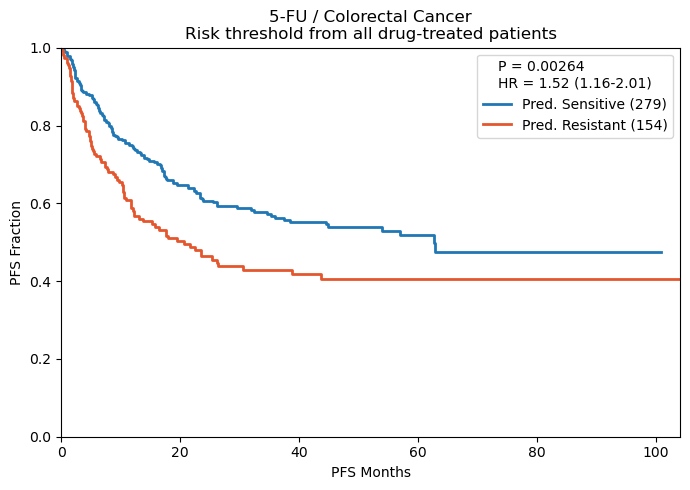

In [85]:
df3 = stratify_drug_cancer_by_risk_score(
    survival_table=survival_table4,
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    drug_name="5-FU",
    cancer_type="Colorectal Cancer",
    threshold_scope="drug_only",
    #output_svg="gemcitabine_pancreatic_risk_km.svg",
)

### Stratify by AUC

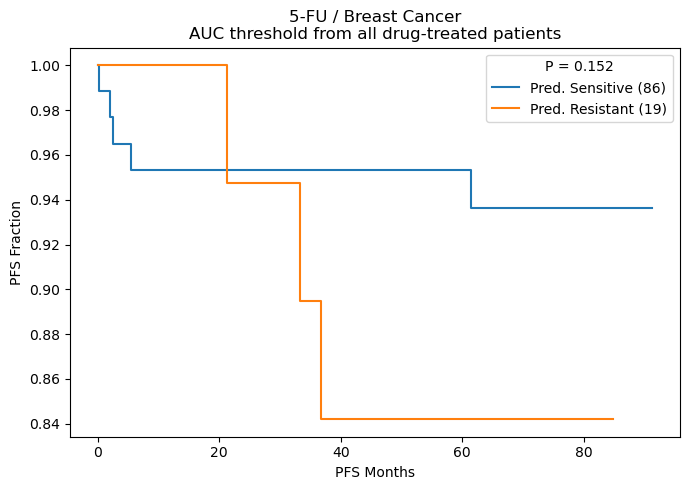

In [375]:
df2 = stratify_drug_cancer_by_predicted_auc(
    survival_table="msk_drpt_transfer_3_survival_probabilities.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    drug_name="5-FU",
    cancer_type="Breast Cancer",
    threshold_scope="drug_only",
    output_svg="5-FU_breast_auc_km.svg",
)

### Stratify by optimized risk score

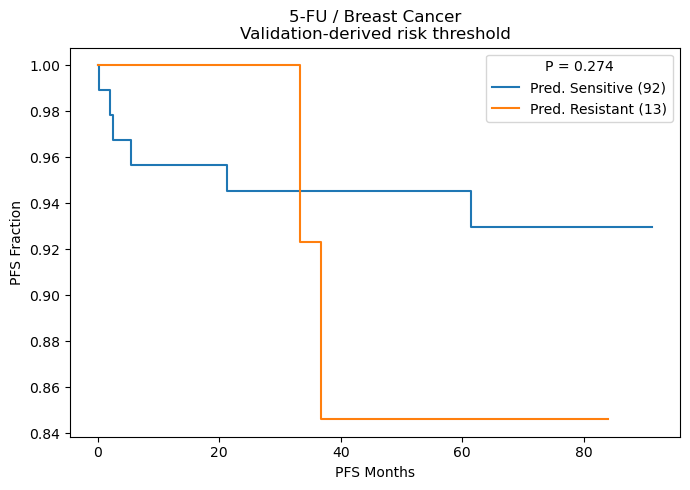

In [32]:
df_thresh = stratify_drug_cancer_by_risk_score_threshold(
    survival_table="msk_embedding_transfer_mlp_cox_ph_risk_optimized_1_test_risk_assignments.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    drug_name="5-FU",
    cancer_type="Breast Cancer",
    #output_svg="cisplatin_lung_threshold_km.svg",
)

## Special Case - 5-FU+Camptothecin Pancreatic Cancer

In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


def median_surv_time(curve, t_grid):
    below = np.where(curve <= 0.5)[0]
    return t_grid[below[0]] if below.size else t_grid[-1]


def stratify_pancreatic_5fu_camptothecin_from_survival_table(
    survival_table="msk_drpt_transfer_survival_probabilities.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
):
    surv_df = pd.read_csv(survival_table, sep="\t")
    patient_df = pd.read_csv(patient_table, sep="\t")

    required_surv = {"PATIENT_ID", "SAMPLE_ID", "RSI_DRUG", "PFS_MONTHS"}
    required_patient = {
        "PATIENT_ID", "SAMPLE_ID", "RSI_DRUG", "RSI_START_DATE",
        "CANCER_TYPE", "PFS_MONTHS", "PFS_STATUS"
    }

    missing_surv = required_surv - set(surv_df.columns)
    if missing_surv:
        raise ValueError("Missing columns in survival table: {}".format(missing_surv))

    missing_patient = required_patient - set(patient_df.columns)
    if missing_patient:
        raise ValueError("Missing columns in patient table: {}".format(missing_patient))

    time_cols = [c for c in surv_df.columns if c.startswith("time_")]
    if not time_cols:
        raise ValueError("No survival probability columns found in survival table.")

    times = np.array([float(c.replace("time_", "")) for c in time_cols])
    order = np.argsort(times)
    times = times[order]
    time_cols = [time_cols[i] for i in order]

    # Only 5-FU and Camptothecin from the survival table
    surv_sub = surv_df[surv_df["RSI_DRUG"].isin(["5-FU", "Camptothecin"])].copy()
    if surv_sub.empty:
        raise ValueError("No 5-FU or Camptothecin rows found in survival table.")

    # Compute predicted median survival per sample-drug row
    S = surv_sub[time_cols].to_numpy(dtype=float)
    pred_median = np.array([median_surv_time(S[i], times) for i in range(S.shape[0])])
    surv_sub["predicted_median_survival"] = pred_median

    # Drug-specific thresholds from the full drug cohorts in the survival table
    drug_thresholds = (
        surv_sub.groupby("RSI_DRUG")["predicted_median_survival"]
        .median()
        .to_dict()
    )

    surv_sub["predicted_group"] = surv_sub.apply(
        lambda r: "sensitive" if r["predicted_median_survival"] >= drug_thresholds[r["RSI_DRUG"]] else "resistant",
        axis=1
    )

    # Now identify pancreatic patients treated with both drugs at the same RSI_START_DATE
    patient_sub = patient_df[
        (patient_df["CANCER_TYPE"] == "Pancreatic Cancer") &
        (patient_df["RSI_DRUG"].isin(["5-FU", "Camptothecin"]))
    ].copy()

    combo_keys = (
        patient_sub.groupby(["PATIENT_ID", "RSI_START_DATE"])["RSI_DRUG"]
        .apply(lambda s: set(s.dropna()))
        .reset_index(name="drug_set")
    )

    combo_keys = combo_keys[
        combo_keys["drug_set"].apply(lambda s: {"5-FU", "Camptothecin"}.issubset(s))
    ][["PATIENT_ID", "RSI_START_DATE"]]

    if combo_keys.empty:
        raise ValueError("No pancreatic patients found with 5-FU and Camptothecin at the same RSI_START_DATE.")

    combo_rows = patient_sub.merge(combo_keys, on=["PATIENT_ID", "RSI_START_DATE"], how="inner")

    merged = combo_rows.merge(
        surv_sub[
            ["PATIENT_ID", "SAMPLE_ID", "RSI_DRUG", "predicted_median_survival", "predicted_group"]
        ],
        on=["PATIENT_ID", "SAMPLE_ID", "RSI_DRUG"],
        how="inner",
    )

    agg_dict = {
        "SAMPLE_ID": lambda s: ",".join(sorted(set(map(str, s)))),
        "RSI_DRUG": lambda s: sorted(set(s)),
        "predicted_group": lambda s: sorted(set(s)),
        "predicted_median_survival": lambda s: dict(zip(merged.loc[s.index, "RSI_DRUG"], s)),
        "PFS_MONTHS": "first",
        "PFS_STATUS": "first",
    }

    if "EVENT" in surv_df.columns:
        merged = merged.merge(
            surv_df[["PATIENT_ID", "SAMPLE_ID", "RSI_DRUG", "EVENT"]],
            on=["PATIENT_ID", "SAMPLE_ID", "RSI_DRUG"],
            how="left",
        )
        agg_dict["EVENT"] = "first"

    combo_summary = (
        merged.groupby(["PATIENT_ID", "RSI_START_DATE"])
        .agg(agg_dict)
        .reset_index()
        .rename(columns={
            "SAMPLE_ID": "SAMPLE_IDS",
            "RSI_DRUG": "drugs_present",
            "predicted_group": "groups_present",
            "predicted_median_survival": "drug_to_predicted_median",
        })
    )

    combo_summary = combo_summary[
        combo_summary["drugs_present"].apply(lambda x: set(x) == {"5-FU", "Camptothecin"})
    ].copy()

    if combo_summary.empty:
        raise ValueError("No pancreatic combo patients had survival predictions for both 5-FU and Camptothecin.")

    # Resistant if resistant to one or both; sensitive only if sensitive to both
    combo_summary["predicted_group"] = combo_summary["groups_present"].apply(
        lambda groups: "resistant" if "resistant" in groups else "sensitive"
    )

    dur = pd.to_numeric(combo_summary["PFS_MONTHS"]).to_numpy(dtype=float)

    if "EVENT" in combo_summary.columns:
        ev = pd.to_numeric(combo_summary["EVENT"]).astype(int).to_numpy()
    else:
        ev = combo_summary["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    sensitive = (combo_summary["predicted_group"] == "sensitive").to_numpy()
    resistant = (combo_summary["predicted_group"] == "resistant").to_numpy()

    if sensitive.sum() == 0 or resistant.sum() == 0:
        raise ValueError(
            "Need both groups. Found sensitive={}, resistant={}.".format(
                sensitive.sum(), resistant.sum()
            )
        )

    p_value = logrank_test(
        dur[resistant], dur[sensitive],
        event_observed_A=ev[resistant],
        event_observed_B=ev[sensitive],
    ).p_value

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(dur[sensitive], ev[sensitive], label="Predicted sensitive ({})".format(sensitive.sum()))
    kmf.plot_survival_function(ci_show=False)

    kmf.fit(dur[resistant], ev[resistant], label="Predicted resistant ({})".format(resistant.sum()))
    kmf.plot_survival_function(ci_show=False)

    plt.title("Pancreatic Cancer: 5-FU + Camptothecin Combo")
    plt.xlabel("PFS Months")
    plt.ylabel("PFS Fraction")
    plt.grid(True)
    plt.legend(title="P = {:.3g}".format(p_value))
    plt.tight_layout()
    plt.show()

    print("Drug-specific thresholds:")
    for drug, threshold in drug_thresholds.items():
        print("{}: {:.3f}".format(drug, threshold))

    return combo_summary, drug_thresholds


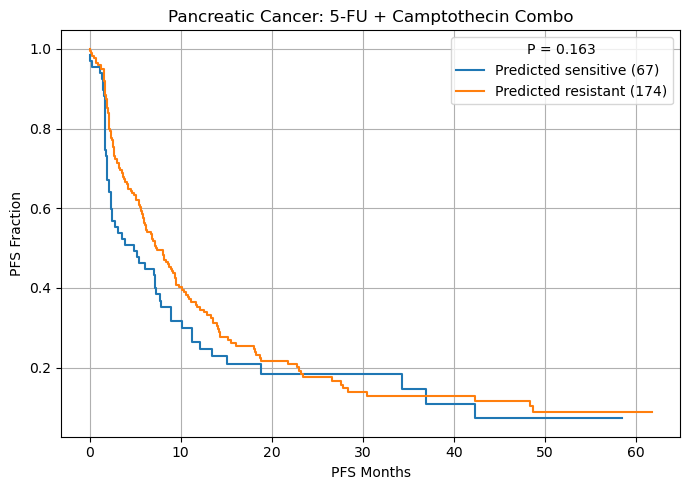

Drug-specific thresholds:
5-FU: 18.351
Camptothecin: 6.477


In [240]:
combo_df, drug_thresholds = stratify_pancreatic_5fu_camptothecin_from_survival_table(
    survival_table=survival_table,
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
)

## New Results that Selected Median Predicted 50% Survival in Test

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


def stratify_sensitive_resistant(
    assignment_table,
    patient_table,
    drug_name,
    cancer_type=None,
):
    assign_df = pd.read_csv(assignment_table, sep="\t")
    patient_df = pd.read_csv(patient_table, sep="\t")

    required_assign = {"SAMPLE_ID", "RSI_DRUG", "predicted_group", "PFS_MONTHS"}
    missing_assign = required_assign - set(assign_df.columns)
    if missing_assign:
        raise ValueError(f"Missing columns in assignment table: {missing_assign}")

    required_patient = {"SAMPLE_ID", "CANCER_TYPE"}
    missing_patient = required_patient - set(patient_df.columns)
    if missing_patient:
        raise ValueError(f"Missing columns in patient table: {missing_patient}")

    merged = assign_df.merge(
        patient_df[["SAMPLE_ID", "CANCER_TYPE"]].drop_duplicates(),
        on="SAMPLE_ID",
        how="left",
    )

    df = merged[merged["RSI_DRUG"] == drug_name].copy()
    if df.empty:
        raise ValueError(f"No rows found for drug: {drug_name}")

    if cancer_type is not None:
        df = df[df["CANCER_TYPE"] == cancer_type].copy()
        if df.empty:
            raise ValueError(f"No rows found for drug={drug_name} and cancer_type={cancer_type}")

    dur = pd.to_numeric(df["PFS_MONTHS"]).to_numpy(dtype=float)
    if "EVENT" in df.columns:
        ev = pd.to_numeric(df["EVENT"]).astype(int).to_numpy()
    else:
        ev = df["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    sensitive = (df["predicted_group"] == "sensitive").to_numpy()
    resistant = (df["predicted_group"] == "resistant").to_numpy()

    if sensitive.sum() == 0 or resistant.sum() == 0:
        raise ValueError(
            f"Need both sensitive and resistant patients to plot. "
            f"Found sensitive={sensitive.sum()}, resistant={resistant.sum()}."
        )

    p_value = logrank_test(
        dur[resistant], dur[sensitive],
        event_observed_A=ev[resistant],
        event_observed_B=ev[sensitive]
    ).p_value

    lbl_sensitive = f"Predicted sensitive ({sensitive.sum()})"
    lbl_resistant = f"Predicted resistant ({resistant.sum()})"

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(dur[sensitive], ev[sensitive], label=lbl_sensitive)
    kmf.plot_survival_function(ci_show=False)

    kmf.fit(dur[resistant], ev[resistant], label=lbl_resistant)
    kmf.plot_survival_function(ci_show=False)

    if cancer_type is None:
        title = f"{drug_name} Kaplan-Meier: Predicted Sensitive vs Resistant"
    else:
        title = f"{drug_name} / {cancer_type}\nKaplan-Meier: Predicted Sensitive vs Resistant"

    plt.title(title)
    plt.xlabel("PFS Months")
    plt.ylabel("PFS Fraction")
    plt.grid(True)
    plt.legend(title=f"P = {p_value:.3g}")
    plt.tight_layout()
    plt.show()

    return df


### With AUC

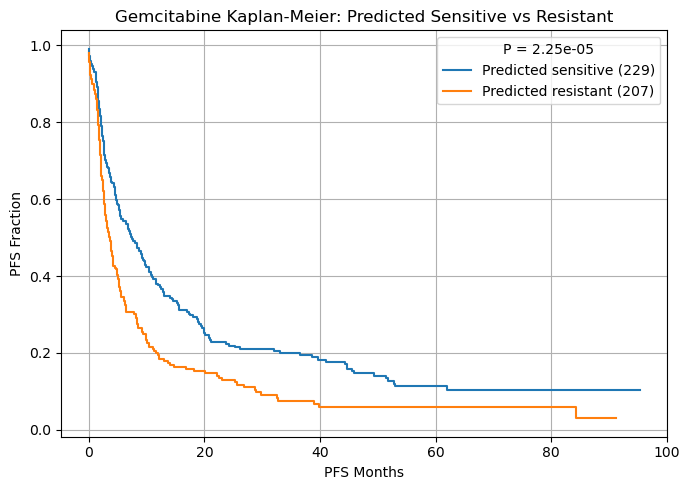

In [190]:
df_out = stratify_sensitive_resistant(
    assignment_table="msk_drpt_transfer_threshold_1_test_assignments.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    drug_name="Gemcitabine",
    #cancer_type="Non-Small Cell Lung Cancer",
)

### Without AUC

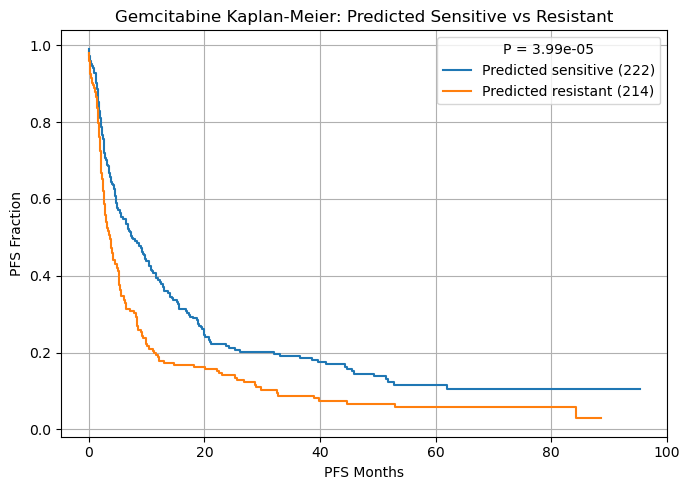

In [191]:
df_out = stratify_sensitive_resistant(
    assignment_table="msk_no_auc_threshold_1_test_assignments.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
    drug_name="Gemcitabine",
    #cancer_type="Colorectal Cancer",
)

## New Results Special Case - 5-FU+Camptothecin Pancreatic Cancer

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


def stratify_pancreatic_5fu_camptothecin_combo(
    assignment_table="msk_drpt_transfer_threshold_1_test_assignments.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
):
    assign_df = pd.read_csv(assignment_table, sep="\t")
    patient_df = pd.read_csv(patient_table, sep="\t")

    required_assign = {"PATIENT_ID", "SAMPLE_ID", "RSI_DRUG", "predicted_group"}
    required_patient = {
        "PATIENT_ID", "SAMPLE_ID", "RSI_DRUG", "RSI_START_DATE",
        "CANCER_TYPE", "PFS_MONTHS", "PFS_STATUS"
    }

    missing_assign = required_assign - set(assign_df.columns)
    if missing_assign:
        raise ValueError("Missing columns in assignment table: {}".format(missing_assign))

    missing_patient = required_patient - set(patient_df.columns)
    if missing_patient:
        raise ValueError("Missing columns in patient table: {}".format(missing_patient))

    patient_sub = patient_df[
        (patient_df["CANCER_TYPE"] == "Pancreatic Cancer") &
        (patient_df["RSI_DRUG"].isin(["5-FU", "Camptothecin"]))
    ].copy()

    combo_keys = (
        patient_sub.groupby(["PATIENT_ID", "RSI_START_DATE"])["RSI_DRUG"]
        .apply(lambda s: set(s.dropna()))
        .reset_index(name="drug_set")
    )

    combo_keys = combo_keys[
        combo_keys["drug_set"].apply(lambda s: {"5-FU", "Camptothecin"}.issubset(s))
    ][["PATIENT_ID", "RSI_START_DATE"]]

    if combo_keys.empty:
        raise ValueError("No pancreatic patients found with 5-FU and Camptothecin at the same RSI_START_DATE.")

    combo_rows = patient_sub.merge(combo_keys, on=["PATIENT_ID", "RSI_START_DATE"], how="inner")

    assign_cols = ["PATIENT_ID", "SAMPLE_ID", "RSI_DRUG", "predicted_group"]
    if "EVENT" in assign_df.columns:
        assign_cols.append("EVENT")

    merged = combo_rows.merge(
        assign_df[assign_cols],
        on=["PATIENT_ID", "SAMPLE_ID", "RSI_DRUG"],
        how="inner",
    )

    agg_dict = {
        "SAMPLE_ID": lambda s: ",".join(sorted(set(map(str, s)))),
        "RSI_DRUG": lambda s: sorted(set(s)),
        "predicted_group": lambda s: sorted(set(s)),
        "PFS_MONTHS": "first",
        "PFS_STATUS": "first",
    }
    if "EVENT" in merged.columns:
        agg_dict["EVENT"] = "first"

    combo_summary = (
        merged.groupby(["PATIENT_ID", "RSI_START_DATE"])
        .agg(agg_dict)
        .reset_index()
        .rename(columns={
            "SAMPLE_ID": "SAMPLE_IDS",
            "RSI_DRUG": "drugs_present",
            "predicted_group": "groups_present",
        })
    )

    combo_summary = combo_summary[
        combo_summary["drugs_present"].apply(lambda x: set(x) == {"5-FU", "Camptothecin"})
    ].copy()

    if combo_summary.empty:
        raise ValueError("No pancreatic combo patients had assignment results for both 5-FU and Camptothecin.")

    combo_summary["predicted_group"] = combo_summary["groups_present"].apply(
        lambda groups: "sensitive" if "sensitive" in groups else "resistant"
    )

    dur = pd.to_numeric(combo_summary["PFS_MONTHS"]).to_numpy(dtype=float)

    if "EVENT" in combo_summary.columns:
        ev = pd.to_numeric(combo_summary["EVENT"]).astype(int).to_numpy()
    else:
        ev = combo_summary["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    sensitive = (combo_summary["predicted_group"] == "sensitive").to_numpy()
    resistant = (combo_summary["predicted_group"] == "resistant").to_numpy()

    if sensitive.sum() == 0 or resistant.sum() == 0:
        raise ValueError(
            "Need both groups. Found sensitive={}, resistant={}.".format(
                sensitive.sum(), resistant.sum()
            )
        )

    p_value = logrank_test(
        dur[resistant], dur[sensitive],
        event_observed_A=ev[resistant],
        event_observed_B=ev[sensitive],
    ).p_value

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(dur[sensitive], ev[sensitive], label="Predicted sensitive ({})".format(sensitive.sum()))
    kmf.plot_survival_function(ci_show=False)

    kmf.fit(dur[resistant], ev[resistant], label="Predicted resistant ({})".format(resistant.sum()))
    kmf.plot_survival_function(ci_show=False)

    plt.title("Pancreatic Cancer: 5-FU + Camptothecin Combo")
    plt.xlabel("PFS Months")
    plt.ylabel("PFS Fraction")
    plt.grid(True)
    plt.legend(title="P = {:.3g}".format(p_value))
    plt.tight_layout()
    plt.show()

    return combo_summary


### With AUC

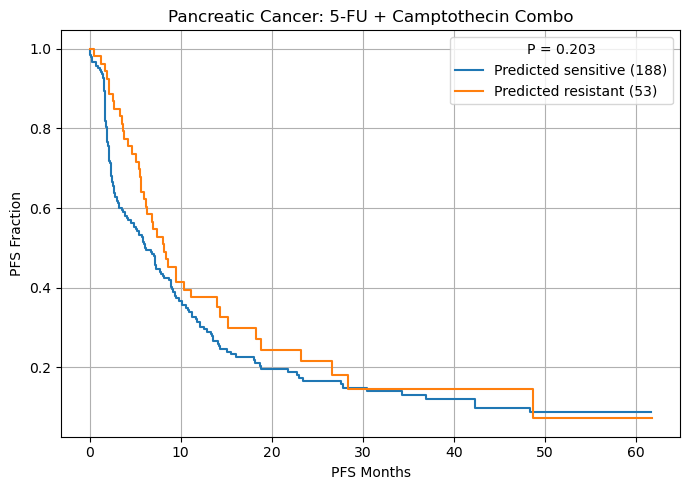

In [165]:
combo_df = stratify_pancreatic_5fu_camptothecin_combo(
    assignment_table="msk_drpt_transfer_threshold_1_test_assignments.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
)


### Without AUC

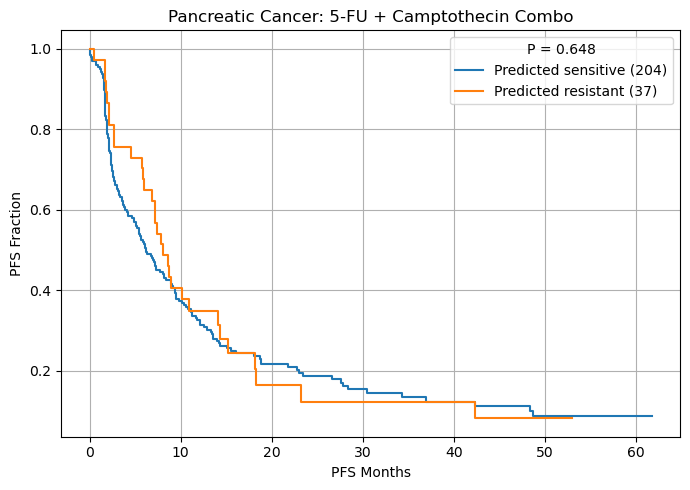

In [166]:
combo_df = stratify_pancreatic_5fu_camptothecin_combo(
    assignment_table="msk_no_auc_threshold_1_test_assignments.tsv",
    patient_table="data/patients/msk_patients_rsi_drugs.txt",
)

# TCGA Analysis

Test the trained TCGA model on the TCGA results

In [54]:
tcga_survival_table = "tcga_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv"

## Stratify by Drug

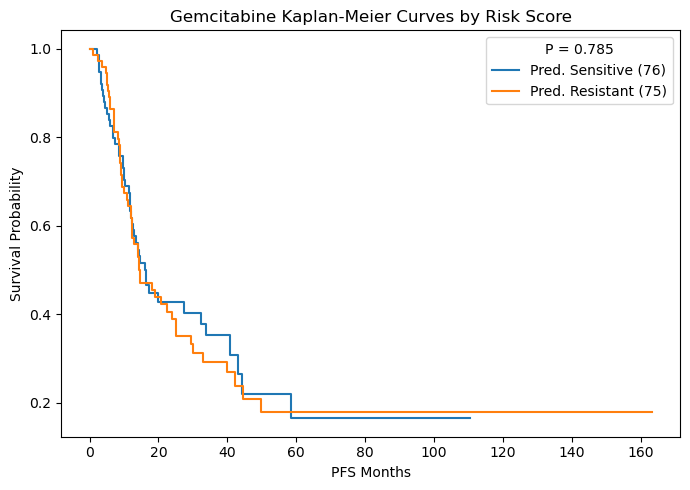

In [39]:
df3 = stratify_by_risk_score(
    survival_table=tcga_survival_table,
    drug_name="Gemcitabine",
    #output_svg="5-fu_risk_km.svg",
)

## Stratify by Cancer Type

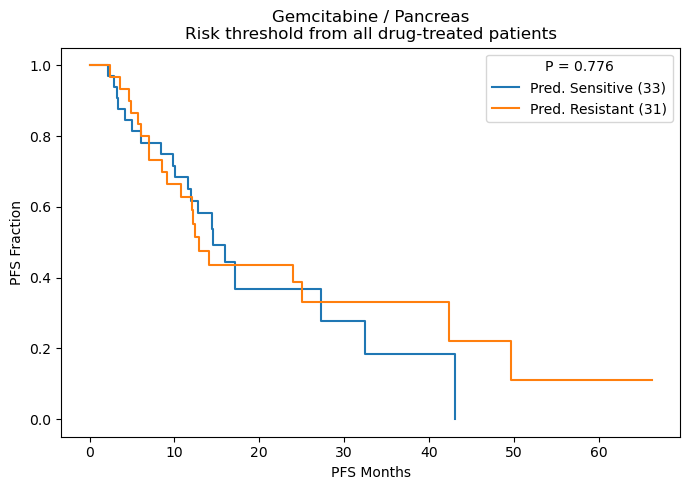

In [56]:
df3 = stratify_drug_cancer_by_risk_score(
    survival_table=tcga_survival_table,
    patient_table="data/patients/tcga_patients_rsi_drugs.txt",
    drug_name="Gemcitabine",
    cancer_type="Pancreas",
    threshold_scope="drug_only",
    #output_svg="5-fu_pancreatic_risk_km.svg",
)

# MSK to TCGA

Validate the model that was transferred using MSK data to TCGA

In [57]:
tcga_val_results = "msk_to_tcga_embedding_transfer_mlp_cox_ph_full_2_tcga_risk_scores.tsv"

## Stratify by drug cohort

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

plt.rcParams["svg.fonttype"] = "none"


def load_tcga_drug_subset(risk_table, drug_name):
    df = pd.read_csv(risk_table, sep="\t")

    required = {"RSI_DRUG", "PFS_MONTHS"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in risk table: {missing}")

    df = df[df["RSI_DRUG"] == drug_name].copy()
    if df.empty:
        raise ValueError(f"No rows found for drug: {drug_name}")

    dur = pd.to_numeric(df["PFS_MONTHS"]).to_numpy(dtype=float)
    if "EVENT" in df.columns:
        ev = pd.to_numeric(df["EVENT"]).astype(int).to_numpy()
    else:
        ev = df["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    return df, dur, ev


def _plot_tcga_km(dur, ev, sensitive_mask, resistant_mask, title, ylabel, output_svg=None):
    p_value = logrank_test(
        dur[resistant_mask], dur[sensitive_mask],
        event_observed_A=ev[resistant_mask],
        event_observed_B=ev[sensitive_mask]
    ).p_value

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(
        dur[sensitive_mask],
        ev[sensitive_mask],
        label=f"Pred. Sensitive ({sensitive_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False)

    kmf.fit(
        dur[resistant_mask],
        ev[resistant_mask],
        label=f"Pred. Resistant ({resistant_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False)

    plt.title(title)
    plt.xlabel("PFS Months")
    plt.ylabel(ylabel)
    plt.grid(False)
    plt.legend(title=f"P = {p_value:.3g}")
    plt.tight_layout()

    if output_svg is not None:
        plt.savefig(output_svg, format="svg", bbox_inches="tight")

    plt.show()
    return p_value


def stratify_tcga_drug_by_msk_threshold(risk_table, drug_name, output_svg=None):
    df, dur, ev = load_tcga_drug_subset(risk_table, drug_name)

    required = {"risk_score", "msk_risk_cutoff"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required MSK-threshold columns: {missing}")

    risk = pd.to_numeric(df["risk_score"]).to_numpy(dtype=float)
    cut = pd.to_numeric(df["msk_risk_cutoff"]).to_numpy(dtype=float)

    if np.isnan(cut).any():
        raise ValueError("Found missing values in msk_risk_cutoff for this drug.")

    sensitive = risk <= cut
    resistant = ~sensitive

    _plot_tcga_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} TCGA Kaplan-Meier by MSK-Derived Threshold",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = df.copy()
    out_df["predicted_group"] = np.where(sensitive, "sensitive", "resistant")
    return out_df


def stratify_tcga_drug_by_tcga_median(risk_table, drug_name, output_svg=None):
    df, dur, ev = load_tcga_drug_subset(risk_table, drug_name)

    if "risk_score" not in df.columns:
        raise ValueError("Missing required column 'risk_score'.")

    risk = pd.to_numeric(df["risk_score"]).to_numpy(dtype=float)
    cut = float(np.median(risk))

    sensitive = risk <= cut
    resistant = ~sensitive

    _plot_tcga_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} TCGA Kaplan-Meier by TCGA Median Risk",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = df.copy()
    out_df["tcga_median_risk_cutoff"] = cut
    out_df["predicted_group"] = np.where(sensitive, "sensitive", "resistant")
    return out_df

### MSK-Threshold

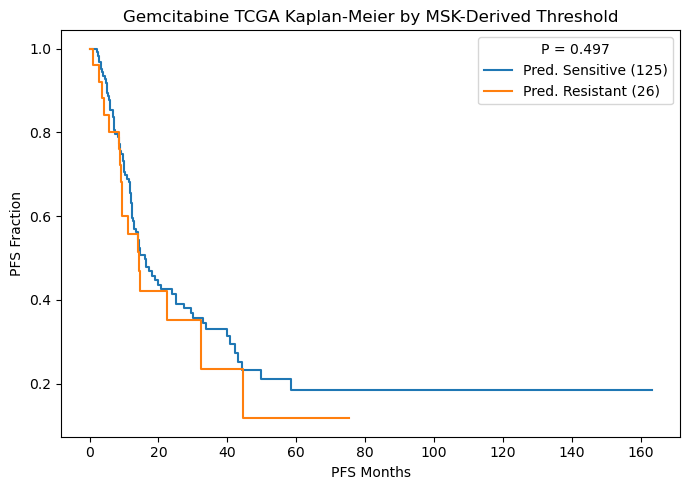

In [59]:
df_msk = stratify_tcga_drug_by_msk_threshold(
    risk_table=tcga_val_results,
    drug_name="Gemcitabine",
    #output_svg="tcga_cisplatin_tcga_median_km.svg",
)

### TCGA Median

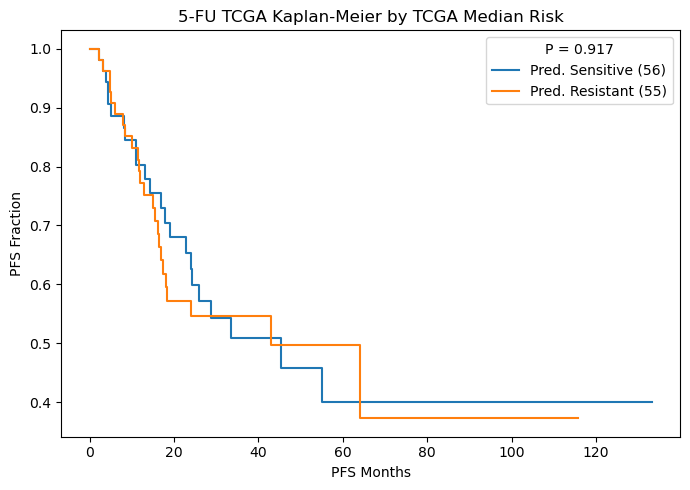

In [61]:
df_tcga = stratify_tcga_drug_by_tcga_median(
    risk_table=tcga_val_results,
    drug_name="5-FU",
    #output_svg="tcga_cisplatin_tcga_median_km.svg",
)

## Stratify by Cancer type

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

plt.rcParams["svg.fonttype"] = "none"


def prepare_tcga_drug_cancer_subset(risk_table, patient_table, drug_name, cancer_type):
    risk_df = pd.read_csv(risk_table, sep="\t")
    patient_df = pd.read_csv(patient_table, sep="\t")

    required_risk = {"SAMPLE_ID", "RSI_DRUG", "PFS_MONTHS"}
    missing_risk = required_risk - set(risk_df.columns)
    if missing_risk:
        raise ValueError(f"Missing required columns in risk table: {missing_risk}")

    required_patient = {"SAMPLE_ID", "CANCER_TYPE"}
    missing_patient = required_patient - set(patient_df.columns)
    if missing_patient:
        raise ValueError(f"Missing required columns in patient table: {missing_patient}")

    merged = risk_df.merge(
        patient_df[["SAMPLE_ID", "CANCER_TYPE"]].drop_duplicates(),
        on="SAMPLE_ID",
        how="left"
    )

    drug_df = merged[merged["RSI_DRUG"] == drug_name].copy()
    if drug_df.empty:
        raise ValueError(f"No rows found for drug: {drug_name}")

    cancer_df = drug_df[drug_df["CANCER_TYPE"] == cancer_type].copy()
    if cancer_df.empty:
        raise ValueError(f"No rows found for drug={drug_name} and cancer_type={cancer_type}")

    dur = pd.to_numeric(cancer_df["PFS_MONTHS"]).to_numpy(dtype=float)
    if "EVENT" in cancer_df.columns:
        ev = pd.to_numeric(cancer_df["EVENT"]).astype(int).to_numpy()
    else:
        ev = cancer_df["PFS_STATUS"].astype(str).str.split(":").str[0].astype(int).to_numpy()

    return drug_df, cancer_df, dur, ev


def _plot_tcga_drug_cancer_km(dur, ev, sensitive_mask, resistant_mask, title, ylabel, output_svg=None):
    p_value = logrank_test(
        dur[resistant_mask], dur[sensitive_mask],
        event_observed_A=ev[resistant_mask],
        event_observed_B=ev[sensitive_mask]
    ).p_value

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(7, 5))

    kmf.fit(
        dur[sensitive_mask],
        ev[sensitive_mask],
        label=f"Pred. Sensitive ({sensitive_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False)

    kmf.fit(
        dur[resistant_mask],
        ev[resistant_mask],
        label=f"Pred. Resistant ({resistant_mask.sum()})"
    )
    kmf.plot_survival_function(ci_show=False)

    plt.title(title)
    plt.xlabel("PFS Months")
    plt.ylabel(ylabel)
    plt.grid(False)
    plt.legend(title=f"P = {p_value:.3g}")
    plt.tight_layout()

    if output_svg is not None:
        plt.savefig(output_svg, format="svg", bbox_inches="tight")

    plt.show()
    return p_value


def stratify_tcga_drug_cancer_by_msk_threshold(
    risk_table,
    patient_table,
    drug_name,
    cancer_type,
    output_svg=None,
):
    drug_df, cancer_df, dur, ev = prepare_tcga_drug_cancer_subset(
        risk_table, patient_table, drug_name, cancer_type
    )

    required = {"risk_score", "msk_risk_cutoff"}
    missing = required - set(cancer_df.columns)
    if missing:
        raise ValueError(f"Missing required MSK-threshold columns: {missing}")

    risk = pd.to_numeric(cancer_df["risk_score"]).to_numpy(dtype=float)
    cut = pd.to_numeric(cancer_df["msk_risk_cutoff"]).to_numpy(dtype=float)

    if np.isnan(cut).any():
        raise ValueError("Found missing values in msk_risk_cutoff for this drug/cancer subset.")

    sensitive = risk <= cut
    resistant = ~sensitive

    _plot_tcga_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nTCGA by MSK-Derived Threshold",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["predicted_group"] = np.where(sensitive, "sensitive", "resistant")
    return out_df


def stratify_tcga_drug_cancer_by_tcga_median(
    risk_table,
    patient_table,
    drug_name,
    cancer_type,
    threshold_scope="drug_only",
    output_svg=None,
):
    """
    threshold_scope:
        - "drug_only": define the TCGA median cutoff using all TCGA patients for that drug
        - "drug_and_cancer": define the TCGA median cutoff using only the TCGA drug+cancer subset
    """
    drug_df, cancer_df, dur, ev = prepare_tcga_drug_cancer_subset(
        risk_table, patient_table, drug_name, cancer_type
    )

    if "risk_score" not in drug_df.columns:
        raise ValueError("Missing required column 'risk_score'.")

    if threshold_scope == "drug_only":
        threshold_df = drug_df
    elif threshold_scope == "drug_and_cancer":
        threshold_df = cancer_df
    else:
        raise ValueError("threshold_scope must be 'drug_only' or 'drug_and_cancer'")

    cut = float(np.median(pd.to_numeric(threshold_df["risk_score"]).to_numpy(dtype=float)))
    risk = pd.to_numeric(cancer_df["risk_score"]).to_numpy(dtype=float)

    sensitive = risk <= cut
    resistant = ~sensitive

    scope_label = "all TCGA patients for the drug" if threshold_scope == "drug_only" else "TCGA drug+cancer subset"
    _plot_tcga_drug_cancer_km(
        dur=dur,
        ev=ev,
        sensitive_mask=sensitive,
        resistant_mask=resistant,
        title=f"{drug_name} / {cancer_type}\nTCGA Median Threshold from {scope_label}",
        ylabel="PFS Fraction",
        output_svg=output_svg,
    )

    out_df = cancer_df.copy()
    out_df["tcga_median_risk_cutoff"] = cut
    out_df["predicted_group"] = np.where(sensitive, "sensitive", "resistant")
    out_df["threshold_scope"] = threshold_scope
    return out_df

### MSK Threshold

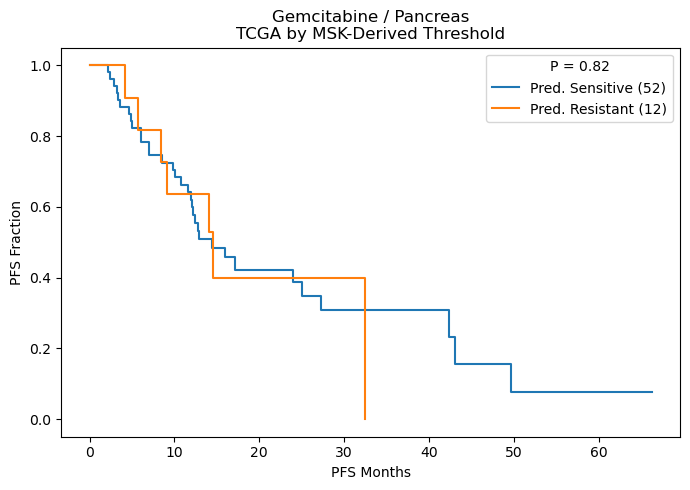

In [63]:
df1 = stratify_tcga_drug_cancer_by_msk_threshold(
    risk_table=tcga_val_results,
    patient_table="data/patients/tcga_patients_rsi_drugs.txt",
    drug_name="Gemcitabine",
    cancer_type="Pancreas",
    #output_svg="tcga_cisplatin_lung_msk_threshold_km.svg",
)

### TCGA Median

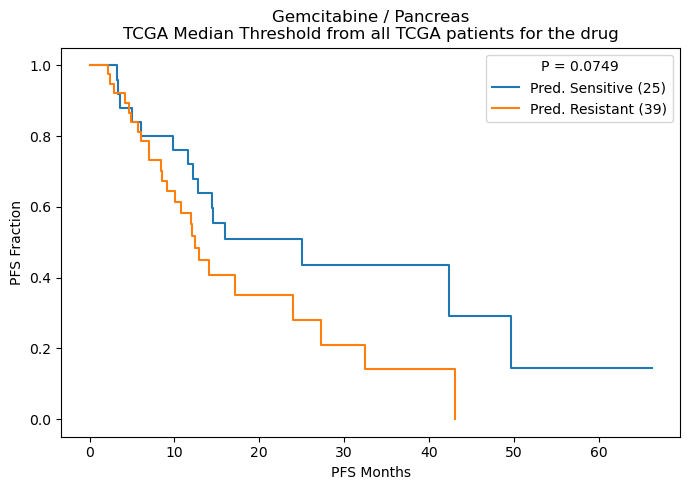

In [53]:
df2 = stratify_tcga_drug_cancer_by_tcga_median(
    risk_table=tcga_val_results,
    patient_table="data/patients/tcga_patients_rsi_drugs.txt",
    drug_name="Gemcitabine",
    cancer_type="Pancreas",
    threshold_scope="drug_only",
    #output_svg="tcga_cisplatin_lung_tcga_median_km.svg",
)


## Analyze Performance with C-Index, Compare Against ElasticNet

In [66]:
import csv
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from scipy.stats import wilcoxon
from sklearn.base import clone
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["svg.fonttype"] = "none"

TASKS = [
    ("5-FU", "Colorectal Cancer", "5-FU\nColorectal"),
    ("Camptothecin", "Colorectal Cancer", "Camptothecin\nColorectal"),
    ("Gemcitabine", "Pancreatic Cancer", "Gemcitabine\nPancreatic"),
]

smiles_to_name = {
    "C1=C(C(=O)NC(=O)N1)F": "5-FU",
    "C1=CN(C(=O)N=C1N)[C@H]2C([C@@H]([C@H](O2)CO)O)(F)F": "Gemcitabine",
    "C1C2CC3CC1CC(C2)(C3)C4=C(C=CC(=C4)C5=CC6=C(C=C5)C=C(C=C6)C(=O)O)O": "CD437",
    "C1CC1C(=O)N2CCN(CC2)C(=O)C3=C(C=CC(=C3)CC4=NNC(=O)C5=CC=CC=C54)F": "Ceralasertib",
    "CC(C)(C1=NC(=CC=C1)N2C3=NC(=NC=C3C(=O)N2CC=C)NC4=CC=C(C=C4)N5CCN(CC5)C)O": "MK-1775",
    "CC1=C(N=C(N=C1N)[C@H](CC(=O)N)NC[C@@H](C(=O)N)N)C(=O)N[C@@H]([C@H](C2=CN=CN2)O[C@H]3[C@H]([C@H]([C@@H]([C@@H](O3)CO)O)O)O[C@@H]4[C@H]([C@H]([C@@H]([C@H](O4)CO)O)OC(=O)N)O)C(=O)N[C@H](C)[C@H]([C@H](C)C(=O)N[C@@H]([C@@H](C)O)C(=O)NCCC5=NC(=CS5)C6=NC(=CS6)C(=O)NCCC[S+](C)C)O": "Bleomycin-a2",
    "CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3=C2)O": "Camptothecin",
    "CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C(=O)N[C@@H](CCC(=O)O)C(=O)O": "Methotrexate",
    "C[C@@H]1COCCN1C2=NC(=NC(=C2)C3(CC3)[S@](=N)(=O)C)C4=C5C=CNC5=NC=C4": "Olaparib",
    "C[C@@H]1OC[C@@H]2[C@@H](O1)[C@@H]([C@H]([C@@H](O2)O[C@H]3[C@H]4COC(=O)[C@@H]4[C@@H](C5=CC6=C(C=C35)OCO6)C7=CC(=C(C(=C7)OC)O)OC)O)O": "Etoposide",
    "C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC3=C2C(=C4C(=C3O)C(=O)C5=C(C4=O)C(=CC=C5)OC)O)(C(=O)CO)O)N)O": "Doxorubicin",
    "N.N.[Cl-].[Cl-].[Pt+2]": "Cisplatin",
}


def encode_event(series):
    return series.astype(str).str.split(":").str[0].astype(int)


def safe_cindex(times, events, score, use_event_observed=True):
    times = np.asarray(times, dtype=float)
    events = np.asarray(events, dtype=int)
    score = np.asarray(score, dtype=float)

    mask = np.isfinite(times) & np.isfinite(score)
    if use_event_observed:
        mask &= np.isfinite(events)

    times = times[mask]
    events = events[mask]
    score = score[mask]

    if len(times) < 2:
        return np.nan
    if np.allclose(score, score[0]):
        return 0.5

    if use_event_observed:
        return float(concordance_index(times, -score, event_observed=events))
    return float(concordance_index(times, -score))


def paired_wilcoxon_greater(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    if len(a) < 2:
        return np.nan

    diffs = a - b
    if np.allclose(diffs, 0):
        return 1.0

    try:
        _, p = wilcoxon(a, b, alternative="greater", zero_method="wilcox")
        return float(p)
    except ValueError:
        return 1.0


def add_sig_bracket(ax, x1, x2, y, h, text="*", lw=1.2):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=lw,
        clip_on=False,
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        color="black",
        clip_on=False,
        zorder=5,
    )


def transform_cindex_axis(y):
    y = np.asarray(y, dtype=float)
    out = y.copy()

    low = y < 0.3
    high = ~low

    out[low] = y[low] / 3.0
    out[high] = y[high] - 0.2

    return out


def load_patient_table(path):
    df = pd.read_csv(path, sep="\t")
    return df[["SAMPLE_ID", "CANCER_TYPE"]].drop_duplicates()


def load_eval_table(path, patient_meta):
    df = pd.read_csv(path, sep="\t")
    df["EVENT"] = encode_event(df["PFS_STATUS"])
    df["PFS_MONTHS"] = pd.to_numeric(df["PFS_MONTHS"], errors="coerce")
    df = df.merge(patient_meta, on="SAMPLE_ID", how="left")
    return df


def load_index_map(path):
    mapping = {}
    with open(path, newline="") as handle:
        reader = csv.reader(handle, delimiter="\t")
        for row in reader:
            if not row:
                continue
            if len(row) >= 2 and row[0].strip().lower() == "index" and row[1].strip().lower() == "sample":
                continue
            mapping[row[1]] = int(row[0])
    return mapping


def load_binary_matrix(path, n_rows=None):
    rows = []

    with open(path, newline="") as handle:
        reader = csv.reader(handle)
        for row in reader:
            if not row:
                continue

            if len(row) == 1:
                values = row[0].strip().strip('"').split(",")
            else:
                values = [v.strip().strip('"') for v in row]

            values = [v for v in values if v != ""]
            rows.append([int(v) for v in values])

    arr = np.asarray(rows, dtype=np.float32)

    if n_rows is not None and arr.shape[0] != n_rows:
        raise ValueError(f"{path}: expected {n_rows} rows, got {arr.shape[0]}")

    return arr


def load_cell_index(cell_index_file):
    df = pd.read_csv(cell_index_file, sep="\t", header=None, engine="python").iloc[:, :2]
    df.columns = ["index", "cell"]
    cell_to_idx = dict(zip(df["cell"].astype(str), df["index"].astype(int)))
    idx_to_cell = dict(zip(df["index"].astype(int), df["cell"].astype(str)))
    return cell_to_idx, idx_to_cell


def load_gene_index(gene_index_file):
    df = pd.read_csv(gene_index_file, sep="\t", header=None, engine="python").iloc[:, :2]
    df.columns = ["index", "gene"]
    return dict(zip(df["index"].astype(int), df["gene"].astype(str)))


def build_feature_matrix(cell_index_file, gene_index_file, mut_file, del_file, amp_file):
    cell_to_idx, idx_to_cell = load_cell_index(cell_index_file)
    n_cells = len(cell_to_idx)
    idx_to_gene = load_gene_index(gene_index_file)
    n_genes = len(idx_to_gene)

    x_mut = load_binary_matrix(mut_file, n_rows=n_cells)
    x_del = load_binary_matrix(del_file, n_rows=n_cells)
    x_amp = load_binary_matrix(amp_file, n_rows=n_cells)

    if x_mut.shape[1] != n_genes or x_del.shape[1] != n_genes or x_amp.shape[1] != n_genes:
        raise ValueError("Gene dimension mismatch.")

    x_all = np.concatenate([x_mut, x_del, x_amp], axis=1)
    return x_all, cell_to_idx, idx_to_cell


def load_response_file(path):
    df = pd.read_csv(path, sep="\t", header=None, engine="python").iloc[:, :4]
    df.columns = ["cell", "smiles", "auc", "db"]
    return df


def train_full_elasticnet_models(
    cell_index_file,
    gene_index_file,
    mut_file,
    del_file,
    amp_file,
    train_files,
):
    x_all, cell_to_idx, _ = build_feature_matrix(
        cell_index_file=cell_index_file,
        gene_index_file=gene_index_file,
        mut_file=mut_file,
        del_file=del_file,
        amp_file=amp_file,
    )

    response_frames = [load_response_file(path) for path in train_files]
    response_df = pd.concat(response_frames, ignore_index=True)
    response_df["drug"] = response_df["smiles"].map(smiles_to_name)
    response_df = response_df.dropna(subset=["drug", "auc"])
    response_df = response_df[response_df["cell"].isin(cell_to_idx.keys())].copy()

    base_model = Pipeline(
        steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=0)),
        ]
    )

    models = {}
    for drug_name, drug_df in response_df.groupby("drug", sort=True):
        drug_df = drug_df.drop_duplicates(subset=["cell", "auc"]).copy()
        train_idx = [cell_to_idx[cell] for cell in drug_df["cell"].tolist()]
        x_train = x_all[train_idx, :]
        y_train = drug_df["auc"].astype(float).values
        if len(y_train) < 2:
            continue
        model = clone(base_model)
        model.fit(x_train, y_train)
        models[drug_name] = model

    return models


def build_patient_feature_matrix(patient_index_file, patient_mut_file, patient_del_file, patient_amp_file):
    sample_to_idx = load_index_map(patient_index_file)
    n_rows = len(sample_to_idx)

    x_mut = load_binary_matrix(patient_mut_file, n_rows=n_rows)
    x_del = load_binary_matrix(patient_del_file, n_rows=n_rows)
    x_amp = load_binary_matrix(patient_amp_file, n_rows=n_rows)

    x_all = np.concatenate([x_mut, x_del, x_amp], axis=1)
    return x_all, sample_to_idx


def predict_elasticnet_for_table(auc_df, elasticnet_models, patient_x, sample_to_idx):
    df = auc_df.copy()
    preds = []
    for _, row in df.iterrows():
        drug = row["RSI_DRUG"]
        sample = row["SAMPLE_ID"]
        if drug not in elasticnet_models or sample not in sample_to_idx:
            preds.append(np.nan)
            continue
        x = patient_x[sample_to_idx[sample], :].reshape(1, -1)
        preds.append(float(elasticnet_models[drug].predict(x)[0]))
    df["elasticnet_auc"] = preds
    return df


def subset_task(df, drug_name, cancer_type):
    return df[(df["RSI_DRUG"] == drug_name) & (df["CANCER_TYPE"] == cancer_type)].copy()


def cindex_by_fold(df, score_col, use_event_observed=True):
    values = []
    for fold, fold_df in sorted(df.groupby("fold"), key=lambda x: str(x[0])):
        cidx = safe_cindex(
            fold_df["PFS_MONTHS"],
            fold_df["EVENT"],
            fold_df[score_col],
            use_event_observed=use_event_observed,
        )
        if np.isfinite(cidx):
            values.append(float(cidx))
    return values


def cindex_pooled(df, score_col, use_event_observed=True):
    return safe_cindex(
        df["PFS_MONTHS"],
        df["EVENT"],
        df[score_col],
        use_event_observed=use_event_observed,
    )


def collect_task_results(risk_df, auc_df, elasticnet_df, evaluation_mode="per_fold", use_event_observed=True):
    labels = []
    drpt_risk_points = []
    drpt_auc_points = []
    elasticnet_points = []
    drpt_risk_heights = []
    drpt_auc_heights = []
    elasticnet_heights = []

    for drug_name, cancer_type, label in TASKS:
        labels.append(label)

        risk_task = subset_task(risk_df, drug_name, cancer_type)
        auc_task = subset_task(auc_df, drug_name, cancer_type)
        en_task = subset_task(elasticnet_df, drug_name, cancer_type)

        if evaluation_mode == "per_fold":
            risk_vals = cindex_by_fold(risk_task, "risk_score", use_event_observed=use_event_observed)
            auc_vals = cindex_by_fold(auc_task, "predicted_auc", use_event_observed=use_event_observed)
            en_vals = cindex_by_fold(en_task, "elasticnet_auc", use_event_observed=use_event_observed)

            drpt_risk_points.append(risk_vals)
            drpt_auc_points.append(auc_vals)
            elasticnet_points.append(en_vals)

            drpt_risk_heights.append(float(np.nanmean(risk_vals)) if risk_vals else np.nan)
            drpt_auc_heights.append(float(np.nanmean(auc_vals)) if auc_vals else np.nan)
            elasticnet_heights.append(float(np.nanmean(en_vals)) if en_vals else np.nan)
        else:
            risk_val = cindex_pooled(risk_task, "risk_score", use_event_observed=use_event_observed)
            auc_val = cindex_pooled(auc_task, "predicted_auc", use_event_observed=use_event_observed)
            en_val = cindex_pooled(en_task, "elasticnet_auc", use_event_observed=use_event_observed)

            drpt_risk_points.append([])
            drpt_auc_points.append([])
            elasticnet_points.append([])

            drpt_risk_heights.append(risk_val)
            drpt_auc_heights.append(auc_val)
            elasticnet_heights.append(en_val)

    return (
        labels,
        drpt_risk_points,
        drpt_auc_points,
        elasticnet_points,
        drpt_risk_heights,
        drpt_auc_heights,
        elasticnet_heights,
    )


def summarize_task_pvalues(drpt_risk_points, drpt_auc_points, elasticnet_points, labels):
    rows = []
    for i, label in enumerate(labels):
        a = np.asarray(drpt_risk_points[i], dtype=float)
        b = np.asarray(drpt_auc_points[i], dtype=float)
        c = np.asarray(elasticnet_points[i], dtype=float)

        rows.append({
            "task": label,
            "p_coxph_gt_auc": paired_wilcoxon_greater(a, b),
            "p_coxph_gt_elasticnet": paired_wilcoxon_greater(a, c),
            "p_auc_gt_elasticnet": paired_wilcoxon_greater(b, c),
        })
    return pd.DataFrame(rows)


def plot_cindex_comparison(
    labels,
    drpt_risk_points,
    drpt_auc_points,
    elasticnet_points,
    drpt_risk_heights,
    drpt_auc_heights,
    elasticnet_heights,
    evaluation_mode="per_fold",
    use_event_observed=True,
    output_svg=None,
    output_png=None,
):
    group_spacing = 0.36
    x = np.arange(len(labels)) * group_spacing
    width = 0.07

    x_risk = x - width
    x_auc = x
    x_en = x + width

    fig, ax = plt.subplots(figsize=(6.4, 5))

    light_grey = "#d9d9d9"
    light_blue = "#8ecae6"
    orange = "#f4a261"
    edge = "#355070"

    risk_h_t = transform_cindex_axis(np.asarray(drpt_risk_heights, dtype=float))
    auc_h_t = transform_cindex_axis(np.asarray(drpt_auc_heights, dtype=float))
    en_h_t = transform_cindex_axis(np.asarray(elasticnet_heights, dtype=float))

    ax.bar(
        x_risk, risk_h_t, width,
        label="DRPT-CoxPH",
        color=light_grey,
        edgecolor=edge,
        linewidth=0.6,
        zorder=2,
    )
    ax.bar(
        x_auc, auc_h_t, width,
        label="DRPT-AUC",
        color=light_blue,
        edgecolor=edge,
        linewidth=0.6,
        zorder=2,
    )
    ax.bar(
        x_en, en_h_t, width,
        label="ElasticNet",
        color=orange,
        edgecolor=edge,
        linewidth=0.6,
        zorder=2,
    )

    if evaluation_mode == "per_fold":
        for i in range(len(labels)):
            if drpt_risk_points[i]:
                yvals = transform_cindex_axis(np.asarray(drpt_risk_points[i], dtype=float))
                ax.scatter(
                    np.full(len(yvals), x_risk[i]),
                    yvals,
                    color=light_grey,
                    edgecolor=edge,
                    linewidth=0.6,
                    s=28,
                    zorder=3,
                )
            if drpt_auc_points[i]:
                yvals = transform_cindex_axis(np.asarray(drpt_auc_points[i], dtype=float))
                ax.scatter(
                    np.full(len(yvals), x_auc[i]),
                    yvals,
                    color=light_blue,
                    edgecolor=edge,
                    linewidth=0.6,
                    s=28,
                    zorder=3,
                )
            if elasticnet_points[i]:
                yvals = transform_cindex_axis(np.asarray(elasticnet_points[i], dtype=float))
                ax.scatter(
                    np.full(len(yvals), x_en[i]),
                    yvals,
                    color=orange,
                    edgecolor=edge,
                    linewidth=0.6,
                    s=28,
                    zorder=3,
                )

        all_points_raw = []
        for vals in drpt_risk_points + drpt_auc_points + elasticnet_points:
            all_points_raw.extend([v for v in vals if np.isfinite(v)])
        all_points_raw = np.asarray(all_points_raw, dtype=float)

        if all_points_raw.size:
            all_points_t = transform_cindex_axis(all_points_raw)
            yr = np.nanmax(all_points_t) - np.nanmin(all_points_t)
        else:
            yr = 0.1

        if yr == 0:
            yr = 0.1

        pad = 0.03 * yr
        h = 0.025 * yr
        stack_gap = 0.02 * yr

        for i in range(len(labels)):
            a = np.asarray(drpt_risk_points[i], dtype=float)
            b = np.asarray(drpt_auc_points[i], dtype=float)
            c = np.asarray(elasticnet_points[i], dtype=float)

            p_ab = paired_wilcoxon_greater(a, b)
            p_ac = paired_wilcoxon_greater(a, c)
            p_bc = paired_wilcoxon_greater(b, c)

            sig_ab = np.isfinite(p_ab) and p_ab < 0.05
            sig_ac = np.isfinite(p_ac) and p_ac < 0.05
            sig_bc = np.isfinite(p_bc) and p_bc < 0.05

            if not (sig_ab or sig_ac or sig_bc):
                continue

            vals_i = np.concatenate([
                a[np.isfinite(a)] if a.size else np.array([]),
                b[np.isfinite(b)] if b.size else np.array([]),
                c[np.isfinite(c)] if c.size else np.array([]),
            ])
            if vals_i.size == 0:
                continue

            y_top = np.nanmax(transform_cindex_axis(vals_i))
            next_y = y_top + pad

            if sig_ab:
                add_sig_bracket(ax, x_risk[i], x_auc[i], next_y, h, "*")
                next_y = next_y + h + stack_gap

            if sig_ac:
                add_sig_bracket(ax, x_risk[i], x_en[i], next_y, h, "*")
                next_y = next_y + h + stack_gap

            if sig_bc:
                add_sig_bracket(ax, x_auc[i], x_en[i], next_y, h, "*")
                next_y = next_y + h + stack_gap

    ax.axhline(transform_cindex_axis(np.array([0.5]))[0], color="red", linestyle="--", linewidth=1.2, zorder=1)

    tick_vals = np.array([0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
    tick_pos = transform_cindex_axis(tick_vals)

    ax.set_ylabel("C-index", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels([f"{v:.1f}" for v in tick_vals])
    ax.set_ylim(0.0, transform_cindex_axis(np.array([0.8]))[0] + 0.08)
    ax.grid(False)
    ax.legend(fontsize=10, frameon=False)
    ax.set_title("")

    y_top_spine = transform_cindex_axis(np.array([0.8]))[0]
    ax.spines["top"].set_position(("data", y_top_spine))
    ax.spines["left"].set_bounds(0.0, y_top_spine)
    ax.spines["right"].set_bounds(0.0, y_top_spine)

    if use_event_observed:
        ax.text(
            0.01, 0.98, "C-index uses event_observed",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
        )

    fig.tight_layout()

    if output_svg is not None:
        fig.savefig(output_svg, format="svg", bbox_inches="tight")
    if output_png is not None:
        fig.savefig(output_png, dpi=600, bbox_inches="tight")

    plt.show()


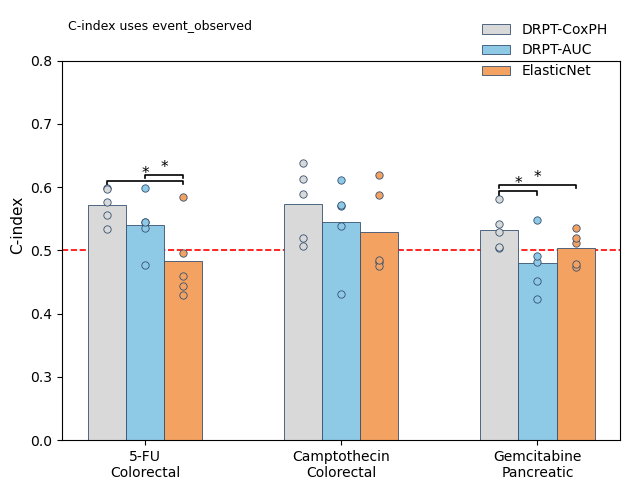

In [67]:
risk_table1 = "msk_embedding_transfer_mlp_cox_ph_risk_1_risk_scores.tsv"
risk_table2 = "msk_embedding_transfer_mlp_cox_ph_risk_0505_risk_scores.tsv"
risk_table3 = "msk_embedding_transfer_mlp_cox_ph_risk_optimized_1_risk_scores.tsv"

auc_table1 = "msk_drpt_transfer_3_survival_probabilities.tsv"
auc_table2 = "msk_embedding_transfer_mlp_cox_ph_risk_0505_risk_scores.tsv"

risk_table = risk_table2
auc_table = auc_table2
patient_table = "data/patients/msk_patients_rsi_drugs.txt"

cell_index_file = "data/cell2ind_av.txt"
gene_index_file = "data/gene2ind_ctg_av.txt"
cell_mut_file = "data/cell2mutation_ctg_av.txt"
cell_del_file = "data/cell2cndeletion_ctg_av.txt"
cell_amp_file = "data/cell2cnamplification_ctg_av.txt"

patient_mut_file = "data/patients/cell2mutation_msk.txt"
patient_del_file = "data/patients/cell2cndeletion_msk.txt"
patient_amp_file = "data/patients/cell2cnamplification_msk.txt"
patient_index_file = "data/patients/patient2ind_msk.txt"

train_files = [f"data/train_splits/full_train_rsi_{i}.txt" for i in range(5)]

use_event_observed = True

patient_meta = load_patient_table(patient_table)
risk_df = load_eval_table(risk_table, patient_meta)
auc_df = load_eval_table(auc_table, patient_meta)

elasticnet_models = train_full_elasticnet_models(
    cell_index_file=cell_index_file,
    gene_index_file=gene_index_file,
    mut_file=cell_mut_file,
    del_file=cell_del_file,
    amp_file=cell_amp_file,
    train_files=train_files,
)

patient_x, patient_sample_to_idx = build_patient_feature_matrix(
    patient_index_file=patient_index_file,
    patient_mut_file=patient_mut_file,
    patient_del_file=patient_del_file,
    patient_amp_file=patient_amp_file,
)

elasticnet_df = predict_elasticnet_for_table(
    auc_df=auc_df,
    elasticnet_models=elasticnet_models,
    patient_x=patient_x,
    sample_to_idx=patient_sample_to_idx,
)

(
    labels,
    drpt_risk_points,
    drpt_auc_points,
    elasticnet_points,
    drpt_risk_heights,
    drpt_auc_heights,
    elasticnet_heights,
) = collect_task_results(
    risk_df=risk_df,
    auc_df=auc_df,
    elasticnet_df=elasticnet_df,
    evaluation_mode="per_fold",   # or "pooled"
    use_event_observed=use_event_observed,
)

plot_cindex_comparison(
    labels=labels,
    drpt_risk_points=drpt_risk_points,
    drpt_auc_points=drpt_auc_points,
    elasticnet_points=elasticnet_points,
    drpt_risk_heights=drpt_risk_heights,
    drpt_auc_heights=drpt_auc_heights,
    elasticnet_heights=elasticnet_heights,
    evaluation_mode="per_fold",
    use_event_observed=use_event_observed,
    output_svg="drpt_vs_auc_vs_elasticnet_cindex.svg",
    output_png="drpt_vs_auc_vs_elasticnet_cindex.png",
)